In [1]:
# first let us get a coin with with several tweets made about it.
import pandas as pd

tweets_df = pd.read_csv('data/post/tweets_resolved.csv')
coins_df = pd.read_csv('data/post/main_3.csv')
pd.set_option('display.max_columns', None)

In [2]:
all_coins = set(coins_df['coin_address'].unique().tolist())
known_coins = set(tweets_df['coin_address'].unique().tolist())
print(len(all_coins))
print(len(known_coins))

4134
321


In [3]:
from tqdm import tqdm
coin_data = {}

for coin in tqdm(all_coins):
    # tweets data
    dedicated_tweets = tweets_df[tweets_df['coin_address'] == coin]

    tweets_list = dedicated_tweets["tweet_text"].tolist()
    tweet_created_at_list = dedicated_tweets["tweet_created_at"].tolist()
    sentiment_list = dedicated_tweets["tweet_sentiment_label"].tolist()
    sentiment_prob_list = dedicated_tweets["tweet_sentiment_label_prob"].tolist()
    engagement_list = dedicated_tweets["tweet_engagement_score"].tolist()
    user_id_list = dedicated_tweets["user_id"].tolist()
    user_followers_count_list = dedicated_tweets["user_followers_count"].tolist()
    user_following_count_list = dedicated_tweets["user_following_count"].tolist()
    user_created_at_list = dedicated_tweets["user_created_at"].tolist()
    verified_list = dedicated_tweets["verified"].tolist()
    is_blue_verified_list = dedicated_tweets["is_blue_verified"].tolist()
    
    # get coin row from coins_df
    c = coins_df.loc[coins_df["coin_address"] == coin].to_dict()
    id = list(c["id"].keys())[0]
    exchange = c["exchange"][id]
    pair_address = c["pair_address"][id]
    creation_timestamp = c["creation_timestamp"][id]
    creator = c["creator"][id]
    initial_liquidity = c["initial_liquidity"][id]
    initial_price = c["initial_price"][id]
    ath_time_delta = c["ath_time_delta"][id]
    ath_price_gain = c["ath_price_gain"][id]
    rugpull_flag = c["rugpull_flag"][id]
    rugpull_timestamp = c["rugpull_timestamp"][id]
    rugpull_time_delta = c["rugpull_time_delta"][id]
    outcomes = c["outcomes"][id]

    coin_data[coin] = {
        "tweets_list": tweets_list,
        "tweet_created_at_list": tweet_created_at_list,
        "sentiment_list": sentiment_list,
        "sentiment_prob_list": sentiment_prob_list,
        "engagement_list": engagement_list,
        "user_id_list": user_id_list,
        "user_followers_count_list": user_followers_count_list,
        "user_following_count_list": user_following_count_list,
        "user_created_at_list": user_created_at_list,
        "verified_list": verified_list,
        "is_blue_verified_list": is_blue_verified_list,
        "exchange": exchange,
        "pair_address": pair_address,
        "creation_timestamp": creation_timestamp,
        "creator": creator,
        "initial_liquidity": initial_liquidity,
        "initial_price": initial_price,
        "ath_time_delta": ath_time_delta,
        "ath_price_gain": ath_price_gain,
        "rugpull_flag": rugpull_flag,
        "rugpull_timestamp": rugpull_timestamp,
        "rugpull_time_delta": rugpull_time_delta,
        "outcomes": outcomes,
    }


100%|██████████| 4134/4134 [00:05<00:00, 752.50it/s]


In [71]:
# sort_coins_by_tweets
sorted_coins = sorted(coin_data, key=lambda x: len(coin_data[x]["tweets_list"]), reverse=True)

# filter by rugpull_timestamp not pd.isna
# sorted_coins = [coin for coin in sorted_coins if not pd.isna(coin_data[coin]["rugpull_timestamp"])]
most_tweets_coin = sorted_coins[2]
print(most_tweets_coin)
print(len(coin_data[most_tweets_coin]["tweets_list"]))

2iT1EMtMwn8jj3fPDDXzxKbgiowbm8JQahd2EXeYpump
82


In [72]:
import json
with open('coin_data.json', 'w') as f:
    json.dump(coin_data[most_tweets_coin], f)

In [73]:
import yaml
from pathlib import Path
import requests
import pandas as pd
from typing import List
import db_utils
import sys
import time
from tqdm import tqdm
config_path = Path("config.yaml")
config = yaml.safe_load(config_path.read_text()) or {}
base_url = "https://api.geckoterminal.com/api/v2"
AGGREGATES = [1, 5]
RATE_LIMIT_PER_MINUTE = 30
WAIT_TIME_SECONDS = (60 / RATE_LIMIT_PER_MINUTE) + 0.25

def build_ohlcv_url(pair_address: str, network: str = "solana", timeframe: str = "minute", aggregate: int = 1, limit: int = 1000, before_timestamp: int = None) -> str:
    return_url = f"{base_url}/networks/{network}/pools/{pair_address}/ohlcv/{timeframe}?aggregate={aggregate}&limit={limit}"
    if before_timestamp:
        return_url += f"&before_timestamp={before_timestamp}"
    return return_url

def get_ohlcv_data(pair_address: str, limit: int = 1000, aggregate: int = 1, before_timestamp: int = None) -> List[List]:
    ohlcv_list = []
    while True:
        url = build_ohlcv_url(pair_address, before_timestamp=before_timestamp, limit=limit, aggregate=aggregate)
        response = requests.get(url)
        response.raise_for_status()
        time.sleep(WAIT_TIME_SECONDS)
        extension = response.json()["data"]["attributes"]["ohlcv_list"]
        ohlcv_list.extend(extension)
        if len(extension) < limit:
            # no more data to fetch
            break
        before_timestamp = extension[-1][0]
    return ohlcv_list

def resolve_ath(pair_address, token_release_timestamp, rugpull_timestamp):
    found = False
    for aggregate in AGGREGATES:
        try:
            ohlcv_data = get_ohlcv_data(pair_address, limit=1000, aggregate=aggregate, before_timestamp=rugpull_timestamp)
        except Exception as e:
            print(f"Error fetching OHLCV data for {pair_address} with aggregate {aggregate}: {e}")
            return None, None, False
        # get the last timestamp
        if len(ohlcv_data) == 0:
            continue
        last_timestamp = ohlcv_data[-1][0]
        # Get the difference between the last timestamp, and the token release date.
        time_diff = last_timestamp - token_release_timestamp
        max_time_diff = aggregate * 60
        if time_diff < max_time_diff:
            found = True
            break
    if found:
        # original closing price
        original_closing_price = ohlcv_data[-1][4]
        max_closing_price = original_closing_price
        max_timestamp = last_timestamp
        # find the highest closing price
        for ohlcv in ohlcv_data:
            if ohlcv[4] > max_closing_price:
                max_closing_price = ohlcv[4]
                max_timestamp = ohlcv[0]
        # calculate the time delta
        ath_time_delta = max_timestamp - token_release_timestamp
        ath_price_gain = ((max_closing_price - original_closing_price) / original_closing_price) * 100
        return ath_time_delta, ath_price_gain, False
    else:
        return None, None, True


pair_address = coin_data[most_tweets_coin]["pair_address"]
token_release_timestamp = coin_data[most_tweets_coin]["creation_timestamp"]
rugpull_timestamp = coin_data[most_tweets_coin]["rugpull_timestamp"]
rugpull_timestamp = None
if rugpull_timestamp is None or pd.isna(rugpull_timestamp):
    rugpull_timestamp = int(time.time())
resolve_ath(pair_address, token_release_timestamp, rugpull_timestamp)

(7910, 144.55756293141272, False)

In [74]:
coin_data[most_tweets_coin]["ath_time_delta"] = 7910
coin_data[most_tweets_coin]["ath_price_gain"] = 144.55756293141272

In [75]:
coin_data[most_tweets_coin]["exchange"]

'Pump Fun'

FBTwneWSRhmHwnKJeZHvXDDyCpQWhzAwKSQbFHrumKLH


<Axes: title={'center': 'Timeline of key events'}, xlabel='Time (UTC)'>

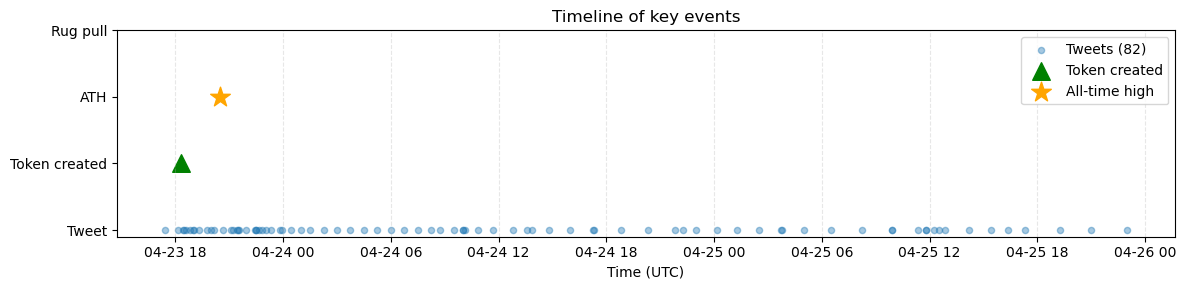

In [76]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timezone
from typing import Any, Mapping, Optional, Sequence

# ─── put / overwrite in plot_helpers.py ────────────────────────────────────────
def event_timeline(
    token_dict: Mapping[str, Any],
    *,
    tz = "UTC",
    ignore: Sequence[str] = (),          # ← NEW
    ax: Optional[plt.Axes] = None,
    figsize: tuple[int, int] = (12, 3),
    tweet_marker_size: int = 20,
    alpha: float = 0.4,
) -> plt.Axes:
    """
    Visualise key timestamps on one horizontal timeline.

    Parameters
    ----------
    token_dict : dict
        Your token-level dictionary.
    tz : str | datetime.tzinfo, default "UTC"
        Time zone used for the x-axis.
    ignore : iterable[str], optional
        Event labels to **omit** from the plot.
        Valid values: {"tweet", "user_created", "token_created", "ath", "rugpull"}
    ax : matplotlib.axes.Axes | None
        Existing axes to draw on; a new figure is created if None.
    """

    ignore = {s.lower() for s in ignore}          # normalise to lower-case set

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    # ── convert timestamps ────────────────────────────────────────────────────
    tweets = pd.to_datetime(token_dict["tweet_created_at_list"], unit="s",
                            utc=True).tz_convert(tz)

    creation_ts = pd.to_datetime(token_dict["creation_timestamp"], unit="s",
                                 utc=True).tz_convert(tz)

    user_created_ts = pd.to_datetime(min(token_dict["user_created_at_list"]),
                                     unit="s", utc=True).tz_convert(tz)

    ath_ts = (pd.to_datetime(token_dict["creation_timestamp"] +
                             token_dict["ath_time_delta"], unit="s", utc=True)
              .tz_convert(tz)
              if pd.notna(token_dict.get("ath_time_delta")) else None)

    rug_ts = (pd.to_datetime(token_dict["rugpull_timestamp"], unit="s", utc=True)
              .tz_convert(tz)
              if token_dict.get("rugpull_flag") == 1 and
                 pd.notna(token_dict.get("rugpull_timestamp")) else None)

    # ── scatter each layer if not ignored ─────────────────────────────────────
    if "tweet" not in ignore:
        ax.scatter(tweets, ["Tweet"] * len(tweets),
                   s=tweet_marker_size, alpha=alpha,
                   label=f"Tweets ({len(tweets)})")

    if "user_created" not in ignore:
        ax.scatter([user_created_ts], ["User created"],
                   marker="o", s=140, color="purple", label="User account created")

    if "token_created" not in ignore:
        ax.scatter([creation_ts], ["Token created"],
                   marker="^", s=160, color="green", label="Token created")

    if ath_ts is not None and "ath" not in ignore:
        ax.scatter([ath_ts], ["ATH"],
                   marker="*", s=220, color="orange", label="All-time high")

    if rug_ts is not None and "rugpull" not in ignore:
        ax.scatter([rug_ts], ["Rug pull"],
                   marker="X", s=180, color="red", label="Rug pull")

    # ── tidy up ───────────────────────────────────────────────────────────────
    # Build y-tick order dynamically based on what was plotted
    order = ["Tweet", "User created", "Token created", "ATH", "Rug pull"]
    ax.set_yticks([label for label in order
                   if label.lower().replace(" ", "_") not in ignore])

    ax.set_xlabel(f"Time ({tz})")
    ax.set_title("Timeline of key events")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.legend(loc="upper right")
    plt.tight_layout()

    return ax

print(coin_data[most_tweets_coin]["pair_address"])
event_timeline(coin_data[most_tweets_coin], ignore=["user_created"])